In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from getdist import plots, MCSamples
from astropy.wcs import WCS
from astropy.coordinates import Angle
from astropy import units as u

In [2]:
path_imgblocks = "./imgblocks/"

## CS82SL013639.16+000818.38

In [3]:
imgblock_1 = fits.open(path_imgblocks + 'imgblock1.fits')

In [4]:
imgblock_1[1].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  150 / Length of data axis 1                          
NAXIS2  =                  150 / Length of data axis 2                          
PCOUNT  =                    0 / number of random group parameters              
GCOUNT  =                    1 / number of random groups                        
NEXTEND =                    0 / number of extnesions                           
EQUINOX =   2.000000000000E+03 / Mean equinox                                   
RADECSYS= 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   2.421000000000E+

### Image positions (RA and DEC in degrees, fk5 ds9):

reference: (24.1631451, 0.1384420)

1: (24.1624011, 0.1379414) & (24.1628248, 0.1376109) & (24.1638961, 0.1381216)

In [5]:
input_file_1 = pd.DataFrame({"RA":[24.1631451, 24.1624011, 24.1628248, 24.1638961], "DEC":[0.1384420, 0.1379414, 0.1376109, 0.1381216]})
input_file_1.head()

,RA,DEC
0,24.163145,0.138442
1,24.162401,0.137941
2,24.162825,0.137611
3,24.163896,0.138122


In [6]:
print("Zeropoint magnitude: ", imgblock_1[1].header["MAGZP"])
print("Exposure time magnitude: ", imgblock_1[1].header["EXPTIME"])
print("Total exposure time magnitude: ", imgblock_1[1].header["TEXPTIME"])

Zeropoint magnitude:  25.83
Exposure time magnitude:  1.0
Total exposure time magnitude:  1640.33


In [7]:
chains_path = "./LOG/sys_1/"

In [8]:
chain_1 = pd.read_csv(chains_path+"bayes.dat",
                    comment='#',
                    names=["N", "lnlog", "x", "y", "emass", "theta", "sigma", "chi"],
                    sep=" ",
                    index_col=False)
chain_1.head()

,N,lnlog,x,y,emass,theta,sigma,chi
0,1,3.005974,0.042839,-0.041348,0.215547,0.800844,434.051079,2.274045
1,1,1.718848,0.089015,-0.045493,0.207928,-4.538364,434.559114,4.848298
2,1,0.742459,0.116917,-0.033260,0.215279,-3.859359,434.461623,6.801075
3,1,3.263622,0.047272,-0.057548,0.272461,-2.100523,434.509672,1.758749
4,1,2.091974,0.076039,-0.037243,0.244850,-3.830107,434.731523,4.102045


Text(0.5, 0, 'sigma')

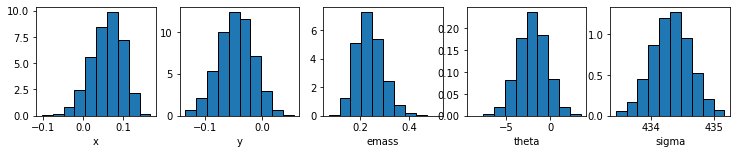

In [9]:
plt.figure(figsize=(15, 2))
plt.tight_layout()

plt.subplot(1,6,1)
plt.hist(chain_1["x"], density = True, ec = "black"); #burning initial steps
plt.xlabel("x")


plt.subplot(1,6,2)
plt.hist(chain_1["y"], density = True, ec = "black"); #burning initial steps
plt.xlabel("y")


plt.subplot(1,6,3)
plt.hist(chain_1["emass"], density = True, ec = "black"); #burning initial steps
plt.xlabel("emass")

plt.subplot(1,6,4)
plt.hist(chain_1["theta"], density = True, ec = "black"); #burning initial steps
plt.xlabel("theta")

plt.subplot(1,6,5)
plt.hist(chain_1["sigma"], density = True, ec = "black"); #burning initial steps
plt.xlabel("sigma")

In [10]:
chain_plot = chain_1.loc[:, chain_1.columns != 'N']
chain_plot = chain_plot.loc[:, chain_plot.columns != 'lnlog']
chain_plot = chain_plot.loc[:, chain_plot.columns != 'chi']

In [11]:
histogramsN = ["x", "y", "emass", "theta", "sigma"]
latexN = ["x", "y", "emass", "theta", "sigma"]

In [12]:
samples_1 = MCSamples(samples=np.array(chain_plot), names = histogramsN, labels = latexN)

Removed no burn in


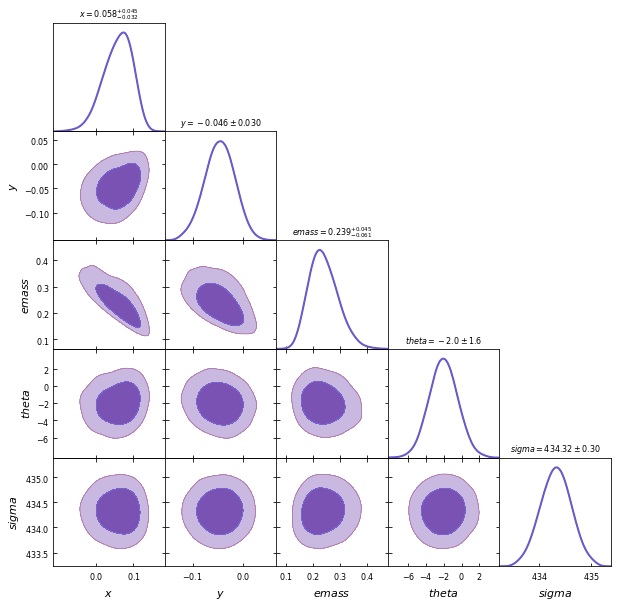

In [13]:
g = plots.get_subplot_plotter()
g.settings.line_labels =False
g.triangle_plot([samples_1, samples_1], filled=True, line_args=[{'lw':1, 'color':'C3'}, {'lw':2, 'color':'slateblue'}],
          contour_colors=['C3','slateblue'], title_limit=1)

## Resultados da Anna

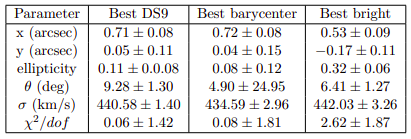

In [14]:
images_1 = pd.read_csv(chains_path+"image.dat",
                    comment='#',
                    usecols = [1,2],
                    names=["RA", "DEC"],
                    sep=" ",
                    index_col=False)
images_1.head()

,RA,DEC
0,24.162401,0.137941
1,24.163897,0.138121
2,24.162398,0.137946
3,24.163002,0.139388
4,24.162825,0.137611


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


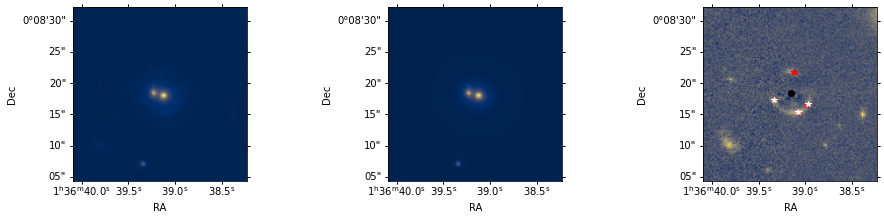

In [15]:
wcs_helix_1 = WCS(imgblock_1[1].header)

fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)


for i in range(1,4):
    ax = fig.add_subplot(1, 3, i, projection=wcs_helix_1)
    ax.imshow(imgblock_1[i].data, cmap='cividis', aspect='equal')
    plt.xlabel(r'RA')
    plt.ylabel(r'Dec')
    if i==3:
        for j in range(0,len(input_file_1)):
            if j==0:
                ax.plot(input_file_1["RA"][j], input_file_1["DEC"][j], 'ko', transform=ax.get_transform('icrs'), zorder=10)
            else:
                ax.plot(input_file_1["RA"][j], input_file_1["DEC"][j], 'w*', transform=ax.get_transform('icrs'), zorder=5)
        for k in range(0, len(images_1)):
            ax.plot(images_1["RA"][k], images_1["DEC"][k], 'r*', transform=ax.get_transform('icrs'), zorder=1)

## CS82SL015824.81-003959.60

In [16]:
imgblock_2 = fits.open(path_imgblocks + 'imgblock2.fits')

In [17]:
imgblock_2[1].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  150 / Length of data axis 1                          
NAXIS2  =                  150 / Length of data axis 2                          
PCOUNT  =                    0 / number of random group parameters              
GCOUNT  =                    1 / number of random groups                        
NEXTEND =                    0 / number of extnesions                           
EQUINOX =   2.000000000000E+03 / Mean equinox                                   
RADECSYS= 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   2.929000000000E+

In [18]:
print("Zeropoint magnitude: ", imgblock_2[1].header["MAGZP"])
print("Exposure time magnitude: ", imgblock_2[1].header["EXPTIME"])
print("Total exposure time magnitude: ", imgblock_2[1].header["TEXPTIME"])

Zeropoint magnitude:  25.83
Exposure time magnitude:  1.0
Total exposure time magnitude:  1640.35


### Image positions (RA and DEC in degrees, fk5 ds9):

reference: (29.6033091, -0.6664364)

1: (29.6024785, -0.6660004) & (29.6024993, -0.6667271)

In [19]:
input_file_2 = pd.DataFrame({"RA":[29.6033091, 29.6024785, 29.6024993], "DEC":[-0.6664364,  -0.6660004, -0.6667271]})
input_file_2.head()

,RA,DEC
0,29.603309,-0.666436
1,29.602479,-0.666000
2,29.602499,-0.666727


In [20]:
chains_path = "./LOG/sys_2/"

In [21]:
chain_2 = pd.read_csv(chains_path+"bayes.dat",
                    comment='#',
                    names=["N", "lnlog", "x", "y", "emass", "theta", "sigma", "chi"],
                    sep=" ",
                    index_col=False)
chain_2.head()

,N,lnlog,x,y,emass,theta,sigma,chi
0,1,-0.781296,0.250700,0.026865,0.982011,-0.039130,431.329138,7.086587
1,1,1.238909,-0.323146,0.016122,1.256440,0.983600,431.373914,3.046177
2,1,0.596760,-0.028585,0.027872,1.092892,1.872839,431.329243,4.330476
3,1,0.716250,-0.141818,0.005426,1.160843,0.565004,431.316981,4.091494
4,1,0.150454,0.093876,0.018054,1.049091,1.223242,431.328560,5.223088


Text(0.5, 0, 'sigma')

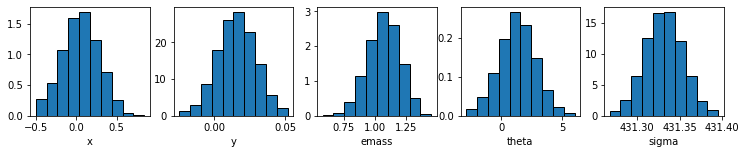

In [22]:
plt.figure(figsize=(15, 2))
plt.tight_layout()

plt.subplot(1,6,1)
plt.hist(chain_2["x"], density = True, ec = "black"); #burning initial steps
plt.xlabel("x")


plt.subplot(1,6,2)
plt.hist(chain_2["y"], density = True, ec = "black"); #burning initial steps
plt.xlabel("y")


plt.subplot(1,6,3)
plt.hist(chain_2["emass"], density = True, ec = "black"); #burning initial steps
plt.xlabel("emass")

plt.subplot(1,6,4)
plt.hist(chain_2["theta"], density = True, ec = "black"); #burning initial steps
plt.xlabel("theta")

plt.subplot(1,6,5)
plt.hist(chain_2["sigma"], density = True, ec = "black"); #burning initial steps
plt.xlabel("sigma")

In [23]:
chain_plot = chain_2.loc[:, chain_2.columns != 'N']
chain_plot = chain_plot.loc[:, chain_plot.columns != 'lnlog']
chain_plot = chain_plot.loc[:, chain_plot.columns != 'chi']

In [24]:
samples_2 = MCSamples(samples=np.array(chain_plot), names = histogramsN, labels = latexN)

Removed no burn in


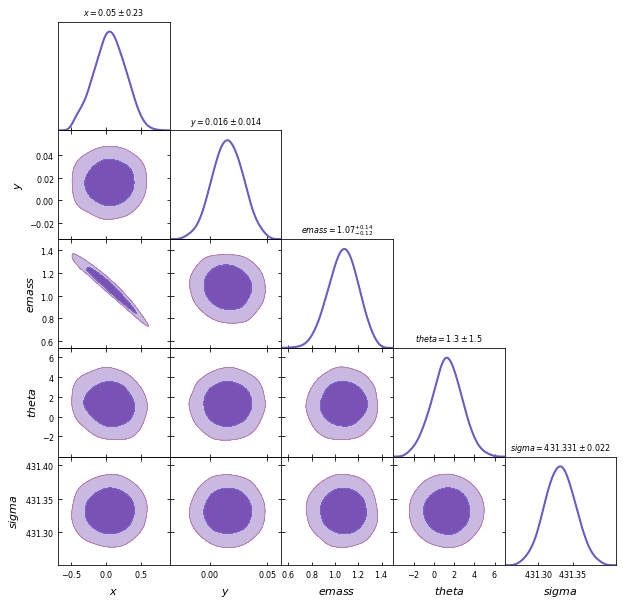

In [25]:
g = plots.get_subplot_plotter()
g.settings.line_labels =False
g.triangle_plot([samples_2, samples_2], filled=True, line_args=[{'lw':1, 'color':'C3'}, {'lw':2, 'color':'slateblue'}],
          contour_colors=['C3','slateblue'], title_limit=1)

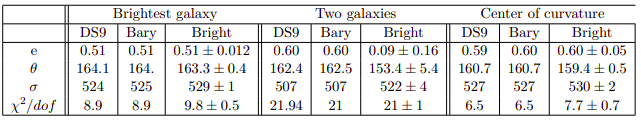

In [26]:
images_2 = pd.read_csv(chains_path+"image.dat",
                    comment='#',
                    usecols = [1,2],
                    names=["RA", "DEC"],
                    sep=" ",
                    index_col=False)
images_2.head()

,RA,DEC
0,29.602479,-0.666000
1,29.602570,-0.665907
2,29.602488,-0.666687


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


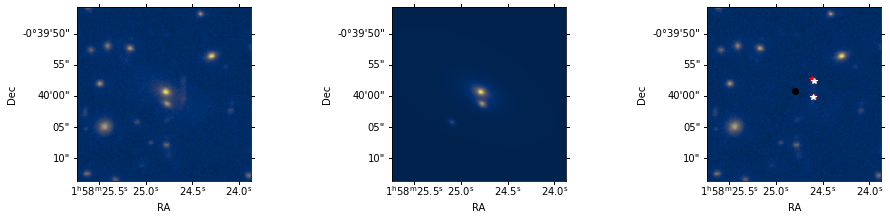

In [30]:
wcs_helix_2 = WCS(imgblock_2[1].header)

fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)


for i in range(1,4):
    ax = fig.add_subplot(1, 3, i, projection=wcs_helix_2)
    ax.imshow(imgblock_2[i].data, cmap='cividis', aspect='equal')
    plt.xlabel(r'RA')
    plt.ylabel(r'Dec')
    if i==3:
        for j in range(0,len(input_file_2)):
            if j==0:
                ax.plot(input_file_2["RA"][j], input_file_2["DEC"][j], 'ko', transform=ax.get_transform('icrs'), zorder=10)
            else:
                ax.plot(input_file_2["RA"][j], input_file_2["DEC"][j], 'w*', transform=ax.get_transform('icrs'), zorder=5)
        for k in range(0, len(images_2)):
            ax.plot(images_2["RA"][k], images_2["DEC"][k], 'r*', transform=ax.get_transform('icrs'), zorder=1)